In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import tree
import matplotlib.pyplot as plt
import joblib as jl
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [2]:
data = pd.read_csv(r"../Data/datasets_formatted.csv")
trimmed = pd.read_csv(r"../Data/dropout_clean_trimmed.csv")
data = data[trimmed.columns]
data = data.drop(columns = "Entry Year")
print(data.shape)

(464739, 11)


In [3]:
from sklearn.model_selection import train_test_split

X = data.drop(columns="Dropout (1=Yes 0=No)")
y = data["Dropout (1=Yes 0=No)"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,          # reproducible
    stratify=y                # keeps dropout ratio equal in both splits
)

clf = tree.DecisionTreeClassifier()
clf.fit(X_train, y_train)
param_grid = {'max_leaf_nodes': range(2, clf.tree_.n_leaves + 1)}

clf_grid = GridSearchCV(clf, param_grid)

clf_grid.fit(X_train, y_train)

path = clf.cost_complexity_pruning_path(X_train, y_train)

param_grid = {'ccp_alpha': path['ccp_alphas']}

clf_grid = GridSearchCV(clf, param_grid)

clf_grid.fit(data22.drop(columns = "Dropout (1=Yes 0=No)"), data22["Dropout (1=Yes 0=No)"]) 

columns = data.columns.drop("Dropout (1=Yes 0=No)")

tree.plot_tree(clf_grid.best_estimator_, feature_names=columns, class_names = ["1", "0"], filled = True)
plt.savefig(r'Figures\BestTreeTrimmed400k.png', dpi = 1500, bbox_inches = 'tight')

In [4]:
clf_grid = jl.load(r'../Models/grid_search.joblib')

In [51]:
from sklearn.metrics import classification_report, confusion_matrix
labels=[1, 0]
CM = confusion_matrix(y_test, y_pred, labels=labels)
y_pred = clf_grid.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred, labels=labels))
print(CM)

              precision    recall  f1-score   support

           1       0.98      0.99      0.99     87026
           0       0.87      0.73      0.79      5922

    accuracy                           0.98     92948
   macro avg       0.92      0.86      0.89     92948
weighted avg       0.97      0.98      0.97     92948

[[86365   661]
 [ 1616  4306]]


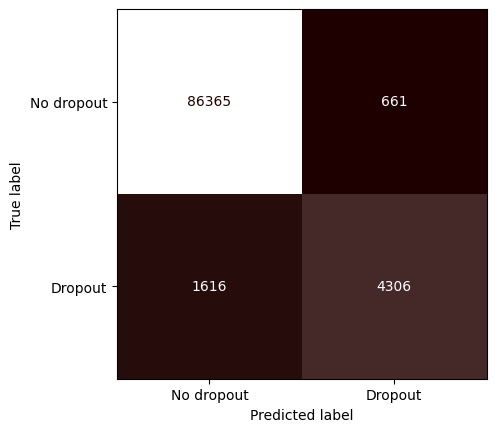

In [40]:
from sklearn.datasets import make_classification
from sklearn.metrics import ConfusionMatrixDisplay
from matplotlib import colormaps
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=labels,
    display_labels=["No dropout", "Dropout"],
    cmap = colormaps["pink"],
    colorbar=False)


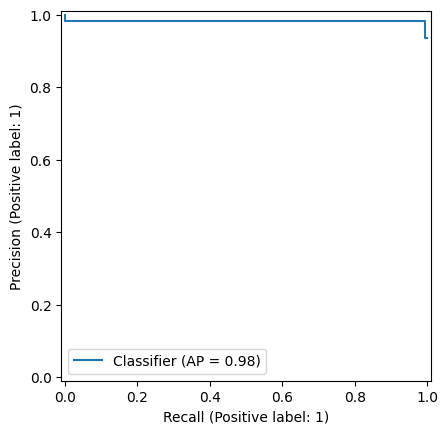

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_predictions(
    y_test, y_pred)

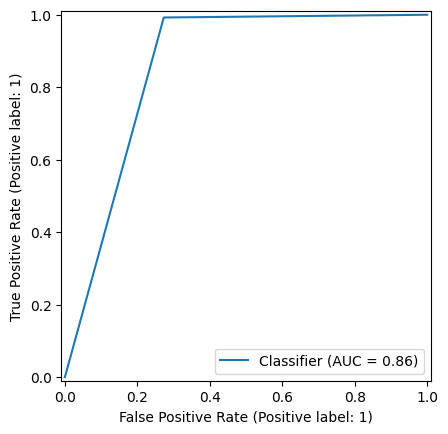

In [52]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(
    y_test, y_pred,
    pos_label=1)

In [7]:
from joblib import dump

dump(clf_grid, "C:\\Users\\MUTYLATOR\\Downloads\\grid_search.joblib")

['C:\\Users\\MUTYLATOR\\Downloads\\grid_search.joblib']